# 测试data_pipeline

In [3]:
from pathlib import Path

# 寻找项目根目录
def find_project_root():
    """从当前目录向上查找项目根目录，兼容从项目根目录或 src 目录启动。"""
    current = Path.cwd().resolve()
    for candidate in (current, *current.parents):
        if (candidate / "src").is_dir() and (candidate / "ninapro_data").is_dir():
            return candidate
    raise FileNotFoundError("未找到同时包含 src 和 ninapro_data 的项目根目录。")


PROJECT_ROOT = find_project_root()

# 将项目根目录添加到 sys.path，以便可以导入 src 包
import sys
sys.path.insert(0, str(PROJECT_ROOT))

In [4]:
from src.data import create_data_pipeline

In [5]:
data_dir = PROJECT_ROOT / "ninapro_data" / "processed" / "exerciseA" / "slide_window"

In [6]:
pipeline = create_data_pipeline(data_dir, batch_size=128)

In [7]:
train_loader = pipeline.train_loader
test_loader = pipeline.test_loader
normalization_state = pipeline.normalization_state_dict()
normalization_state

{'mean': tensor([-1.0049, -1.3482, -0.9008, -0.8748, -0.8460, -0.8622, -0.8555, -0.8586,
         -1.2958, -1.1474, -1.0399, -0.9731, -0.9644, -1.0119, -1.0065, -1.0335]),
 'std': tensor([19.0905, 24.2699,  7.9877,  4.7994,  8.3242, 13.9527, 12.2785, 11.7195,
         24.4487, 18.9145,  6.2835,  5.9839, 13.9063, 14.0657,  9.7216, 15.9752]),
 'eps': 1e-06}

In [ ]:
for x, y in train_loader:
    # ANN 输入：[B, C, T]
    ann_input = x

    display(
        f"ANN 输入形状: {ann_input.shape}, "
        f"ANN 标签形状: {y.shape}"
    )
    display(
        f"ANN 输入示例: {ann_input[0, :, :5]}, "
        f"ANN 标签示例: {y[0]}"
    )
    # SNN 时间优先输入：[T, B, C]
    snn_input = x.permute(2, 0, 1)

    display(
        f"SNN 输入形状: {snn_input.shape}, "
        f"SNN 标签形状: {y.shape}"
    )
    display(
        f"SNN 输入示例: {snn_input[:5, 0, :]}, "
        f"SNN 标签示例: {y[0]}"
    )
    break

'ANN 输入形状: torch.Size([128, 16, 40]), ANN 标签形状: torch.Size([128])'

'ANN 输入示例: tensor([[-5.2123e-02,  5.2408e-01,  5.2641e-02, -2.6165e-01, -1.5689e-01],\n        [-5.2130e-01,  4.6758e-01,  9.6752e-02, -2.6858e-02, -5.2130e-01],\n        [-2.6280e-01,  9.8912e-01, -1.2418e-02, -3.8799e-01, -7.6357e-01],\n        [ 1.8228e-01,  1.8492e+00, -2.6083e-02, -8.5952e-01, -1.0679e+00],\n        [ 5.8215e-01,  1.6633e+00,  1.0163e-01, -4.9903e-01, -9.7955e-01],\n        [ 1.3346e-01,  1.9252e+00,  2.7681e-01, -7.9826e-01, -1.3716e+00],\n        [ 6.9678e-02,  1.0470e+00,  6.3978e-01, -1.1765e-02, -1.0705e+00],\n        [-1.8272e-01,  6.7056e-01,  3.2925e-01, -4.3870e-01, -4.3870e-01],\n        [ 7.0743e-01,  1.7571e-01, -6.8323e-01, -6.0143e-01,  5.3001e-02],\n        [ 8.5370e-01, -9.7949e-02, -8.3812e-01, -2.0369e-01,  6.0660e-02],\n        [ 9.6124e-01, -1.1077e+00, -4.7108e-01,  9.6124e-01,  3.2465e-01],\n        [-1.7162e-01, -2.5112e+00,  5.1761e+00,  1.6667e+00,  8.3108e-01],\n        [-1.7284e+00, -3.6211e-01,  5.0311e+00, -1.0812e+00,  5.7272e-01],\n 

'SNN 输入形状: torch.Size([40, 128, 16]), SNN 标签形状: torch.Size([128])'

'SNN 输入示例: tensor([[-5.2123e-02, -5.2130e-01, -2.6280e-01,  1.8228e-01,  5.8215e-01,\n          1.3346e-01,  6.9678e-02, -1.8272e-01,  7.0743e-01,  8.5370e-01,\n          9.6124e-01, -1.7162e-01, -1.7284e+00,  9.2508e-01,  1.8522e+00,\n          4.4028e-01],\n        [ 5.2408e-01,  4.6758e-01,  9.8912e-01,  1.8492e+00,  1.6633e+00,\n          1.9252e+00,  1.0470e+00,  6.7056e-01,  1.7571e-01, -9.7949e-02,\n         -1.1077e+00, -2.5112e+00, -3.6211e-01, -8.5229e-01, -1.0219e-01,\n          4.4028e-01],\n        [ 5.2641e-02,  9.6752e-02, -1.2418e-02, -2.6083e-02,  1.0163e-01,\n          2.7681e-01,  6.3978e-01,  3.2925e-01, -6.8323e-01, -8.3812e-01,\n         -4.7108e-01,  5.1761e+00,  5.0311e+00,  1.4304e-01, -1.0219e-01,\n         -3.7348e-01],\n        [-2.6165e-01, -2.6858e-02, -3.8799e-01, -8.5952e-01, -4.9903e-01,\n         -7.9826e-01, -1.1765e-02, -4.3870e-01, -6.0143e-01, -2.0369e-01,\n          9.6124e-01,  1.6667e+00, -1.0812e+00, -9.2339e-01, -6.1651e-01,\n         -5.6127e

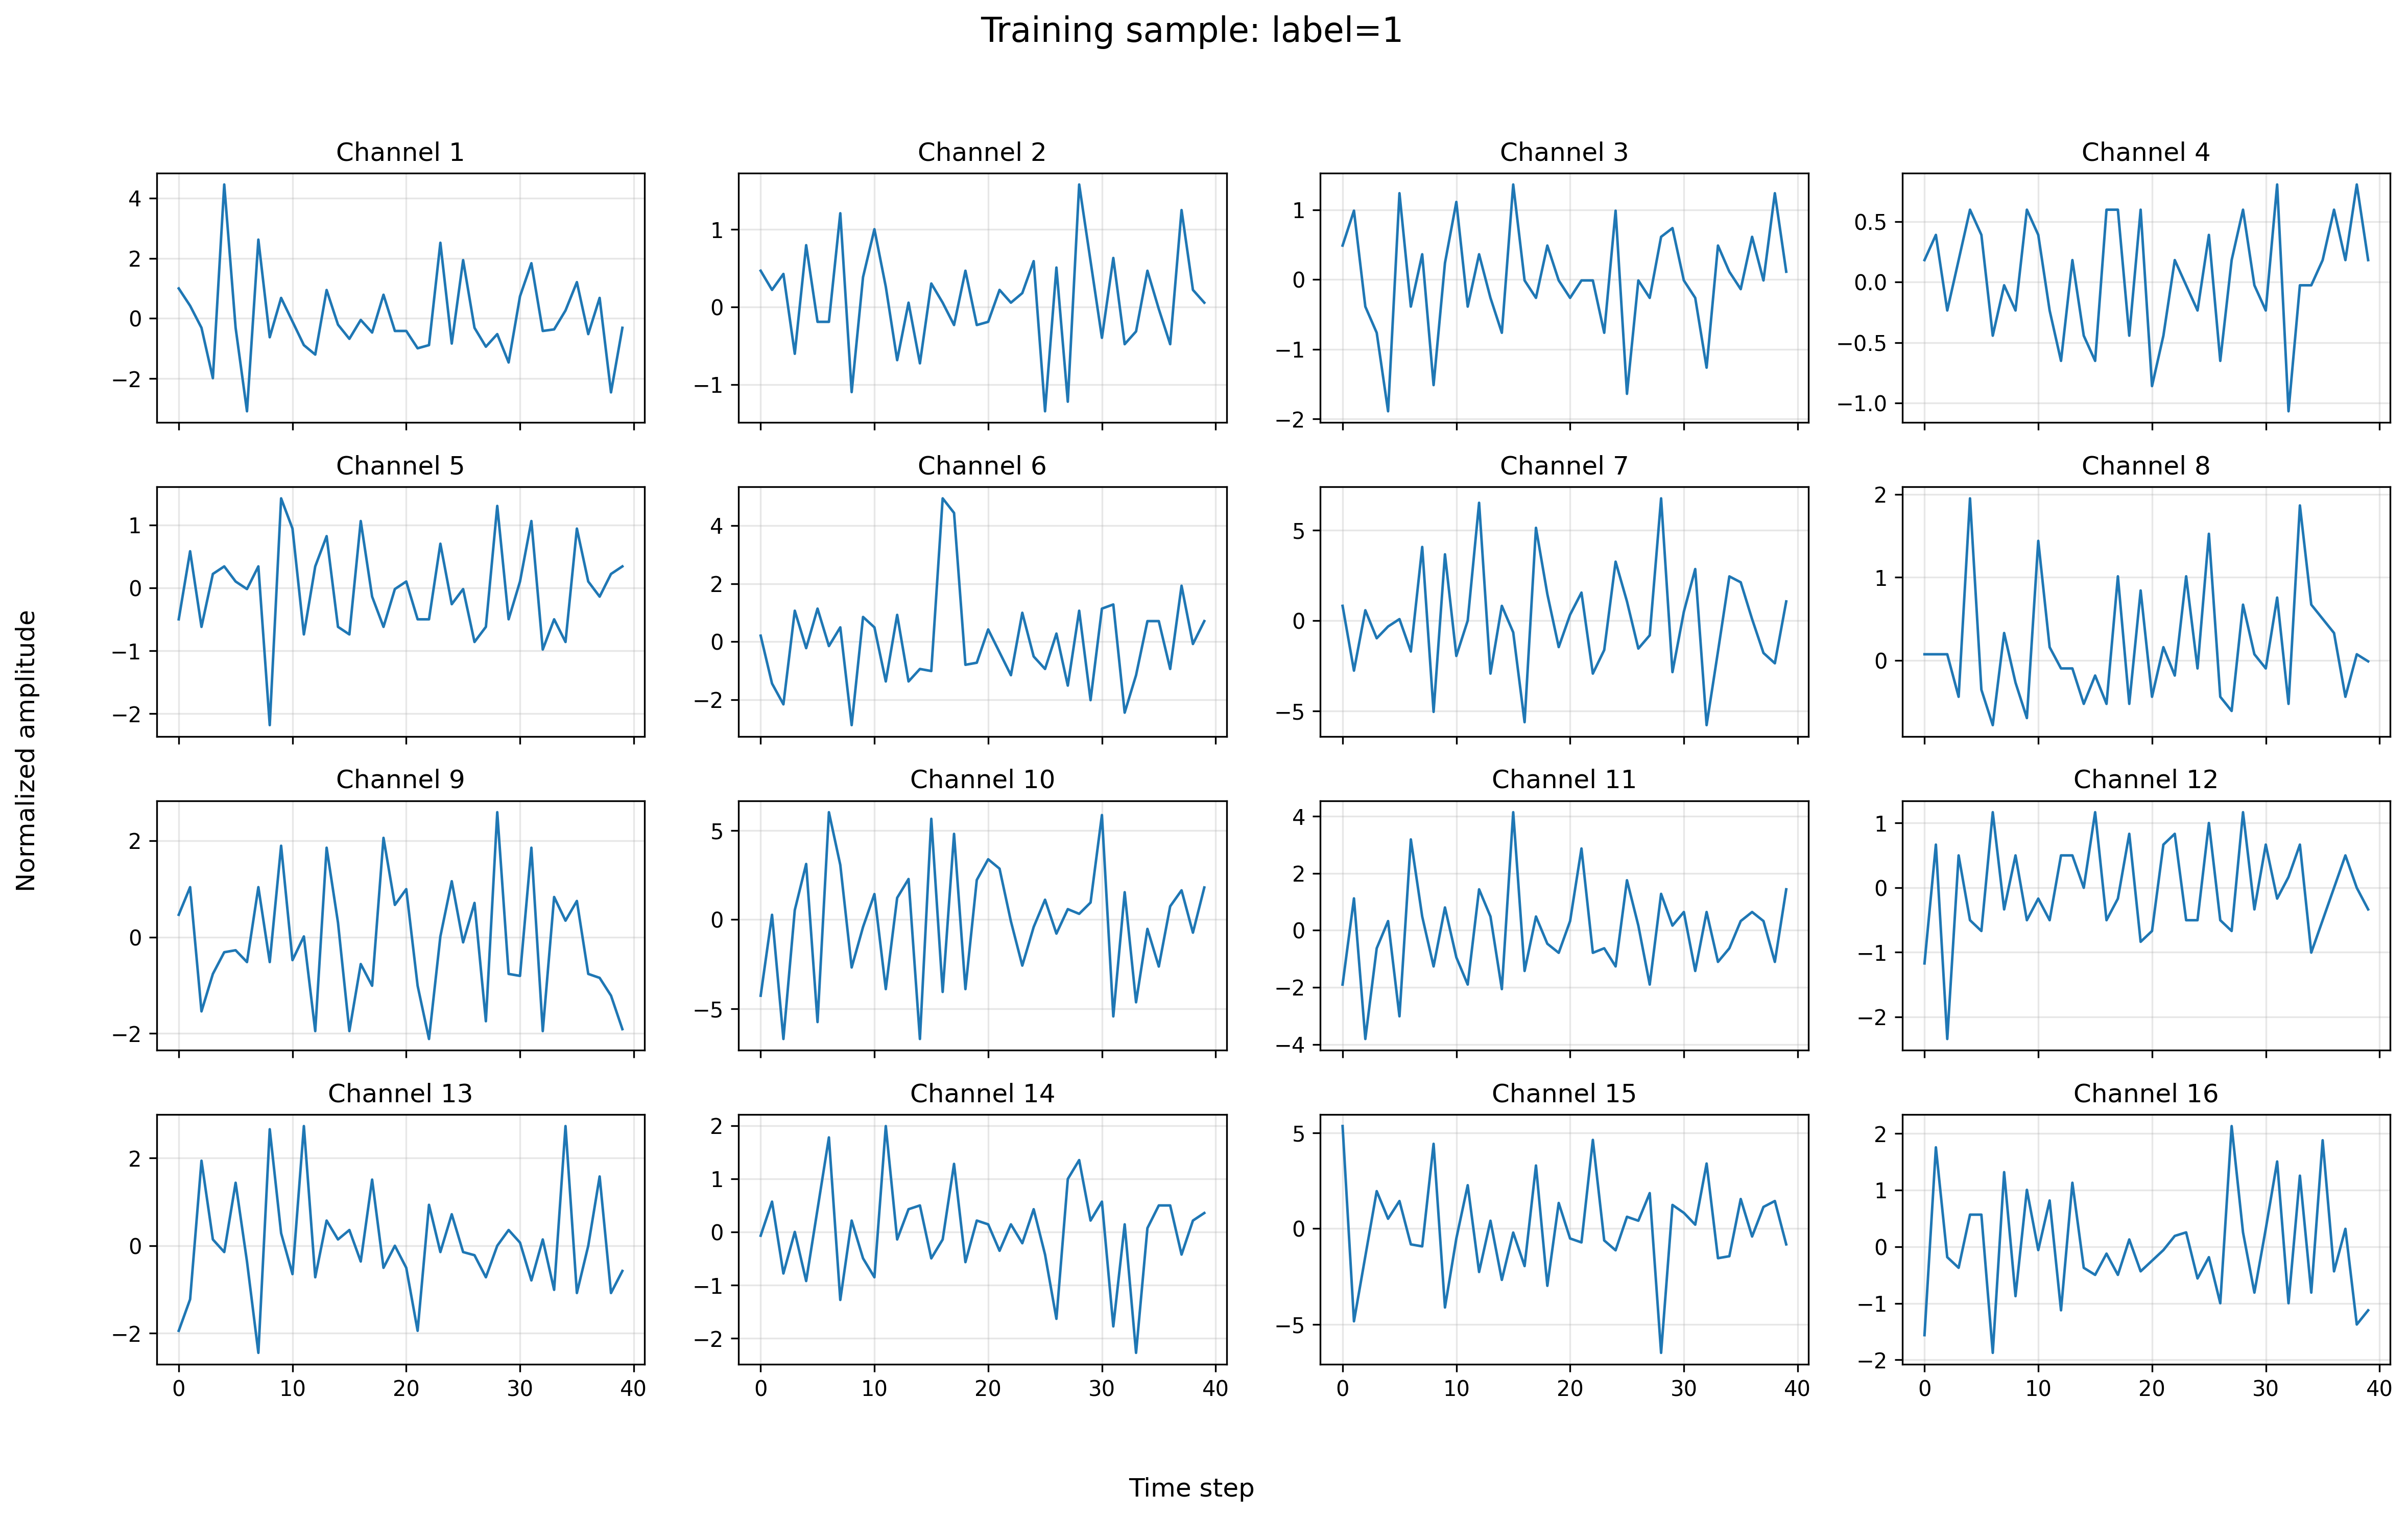

In [9]:
import matplotlib.pyplot as plt

# 从训练集中取一个样本，并转到 CPU 以便 Matplotlib 绘图
train_x, train_y = next(iter(train_loader))
sample = train_x[0].detach().cpu().numpy()
label = train_y[0].item()

if sample.shape[0] != 16:
    raise ValueError(f"期望样本包含 16 个通道，实际形状为 {sample.shape}")

fig, axes = plt.subplots(4, 4, figsize=(16, 10), sharex=True, dpi=300)
time_steps = range(sample.shape[1])

for channel, ax in enumerate(axes.flat):
    ax.plot(time_steps, sample[channel], linewidth=1.2)
    ax.set_title(f"Channel {channel + 1}")
    ax.grid(alpha=0.3)

fig.suptitle(f"Training sample: label={label}", fontsize=16)
fig.supxlabel("Time step")
fig.supylabel("Normalized amplitude")
fig.tight_layout(rect=[0.03, 0.03, 1, 0.95])
plt.show()